<a href="https://colab.research.google.com/github/avinashnaidu2131-gif/Alfido_Task-3/blob/main/Task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import Libraries**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [5]:
from google.colab import files
uploaded = files.upload()

Saving comments.csv to comments.csv
Saving follows.csv to follows.csv
Saving likes.csv to likes.csv
Saving photo_tags.csv to photo_tags.csv
Saving photos.csv to photos.csv
Saving tags.csv to tags.csv
Saving users.csv to users.csv


**Load Dataset**

In [6]:
users = pd.read_csv("users.csv")
photos = pd.read_csv("photos.csv")
likes = pd.read_csv("likes.csv")
comments = pd.read_csv("comments.csv")
tags = pd.read_csv("tags.csv")
photo_tags = pd.read_csv("photo_tags.csv")
follows = pd.read_csv("follows.csv")

**Clean Column Names**

In [7]:
def clean(df):
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
    return df

users = clean(users)
photos = clean(photos)
likes = clean(likes)
comments = clean(comments)
tags = clean(tags)
photo_tags = clean(photo_tags)
follows = clean(follows)

**CHECK COLUMNS**

In [8]:
print("Photos:", photos.columns)
print("Likes:", likes.columns)
print("Comments:", comments.columns)

Photos: Index(['id', 'image_link', 'user_id', 'created_dat', 'insta_filter_used',
       'photo_type'],
      dtype='object')
Likes: Index(['user', 'photo', 'created_time', 'following_or_not', 'like_type'], dtype='object')
Comments: Index(['id', 'comment', 'user__id', 'photo_id', 'created_timestamp',
       'posted_date', 'emoji_used', 'hashtags_used_count'],
      dtype='object')


**DATA MERGING**

**Merge Photos + Users**

In [9]:
df = photos.merge(users, left_on='user_id', right_on='id', suffixes=('_photo','_user'))

**Likes per Photo**

In [10]:
like_counts = likes.groupby('photo').size().reset_index(name='likes')

**Comments per Photo**

In [11]:
comment_counts = comments.groupby('photo_id').size().reset_index(name='comments')

**Merge Engagement**

In [12]:
df = df.merge(like_counts, left_on='id_photo', right_on='photo', how='left')
df = df.merge(comment_counts, left_on='id_photo', right_on='photo_id', how='left')

df['likes'] = df['likes'].fillna(0)
df['comments'] = df['comments'].fillna(0)

FEATURE ENGINEERING

Engagement

In [13]:
df['engagement'] = df['likes'] + df['comments']

**Followers Count**

In [14]:
# Step 1: Create followers count
followers = follows.groupby('followee').size().reset_index()
followers.columns = ['user_id', 'followers']   # rename properly

# Step 2: Merge
df = df.merge(followers, on='user_id', how='left')

# Step 3: Fill missing
df['followers'] = df['followers'].fillna(0)

# Step 4: Engagement rate
df['engagement_rate'] = df['engagement'] / (df['followers'] + 1)

**Engagement Rate**

In [15]:
print(follows.columns)

Index(['follower', 'followee', 'created_time', 'is_follower_active',
       'followee_acc_status'],
      dtype='object')


**Time Features**

In [28]:
followers = follows.groupby('followee').size().reset_index(name='followers')
df = df.merge(followers, left_on='user_id', right_on='followee', how='left')

df['followers_y'] = df['followers_y'].fillna(0)

if 'followers_x' in df.columns:
    df = df.drop(columns=['followers_x'])


df = df.rename(columns={'followers_y': 'followers'})

if 'followee' in df.columns:
    df = df.drop(columns=['followee'])

df = df.reset_index(drop=True)

df['engagement_rate'] = df['engagement'] / (df['followers'] + 1)

In [19]:
df['created_dat'] = pd.to_datetime(df['created_dat'])

df['hour'] = df['created_dat'].dt.hour
df['day'] = df['created_dat'].dt.day_name()

/tmp/ipykernel_3036/2093257966.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['created_dat'] = pd.to_datetime(df['created_dat'])


ANALYSIS

Best Posting Time

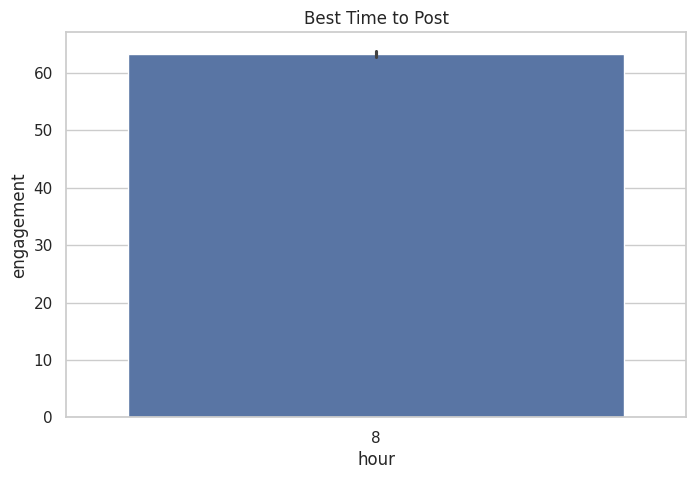

In [20]:
plt.figure(figsize=(8,5))
sns.barplot(x='hour', y='engagement', data=df)
plt.title("Best Time to Post")
plt.show()

**Best Day**

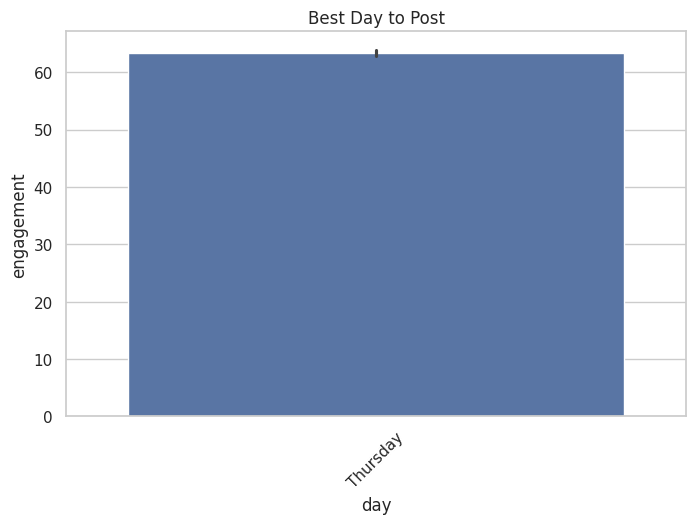

In [21]:
plt.figure(figsize=(8,5))
sns.barplot(x='day', y='engagement', data=df)
plt.xticks(rotation=45)
plt.title("Best Day to Post")
plt.show()

**Content Type**

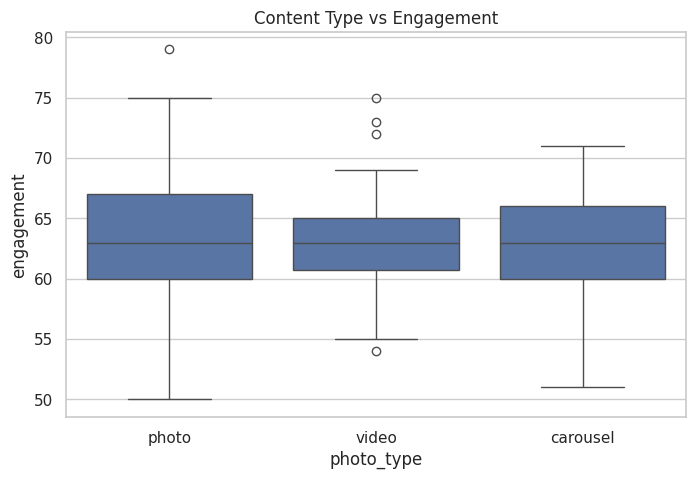

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(x='photo_type', y='engagement', data=df)
plt.title("Content Type vs Engagement")
plt.show()

**Engagement Distribution**

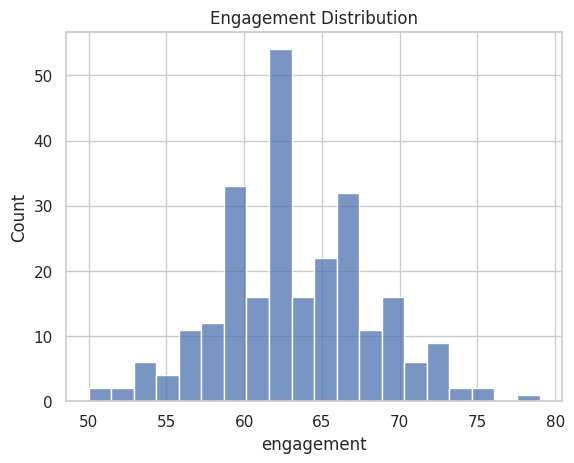

In [23]:
sns.histplot(df['engagement'], bins=20)
plt.title("Engagement Distribution")
plt.show()

HASHTAG ANALYSIS

Merge Tags

In [24]:
tag_data = photo_tags.merge(tags, left_on='tag_id', right_on='id')

**Top Hastags**

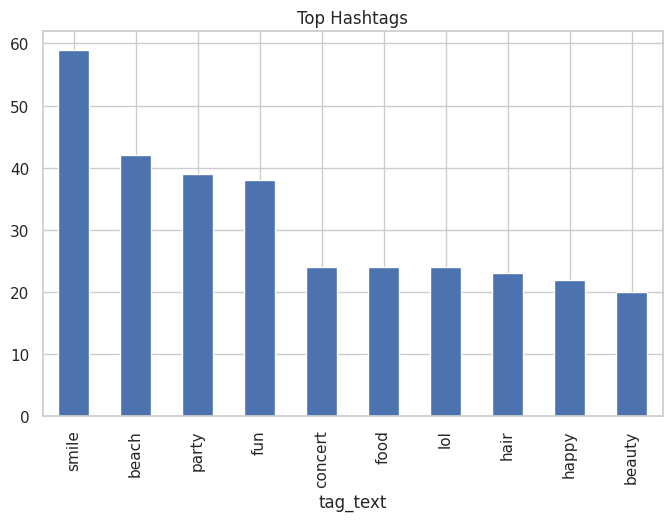

In [25]:
tag_counts = tag_data['tag_text'].value_counts().head(10)

plt.figure(figsize=(8,5))
tag_counts.plot(kind='bar')
plt.title("Top Hashtags")
plt.show()

**Heatmap**

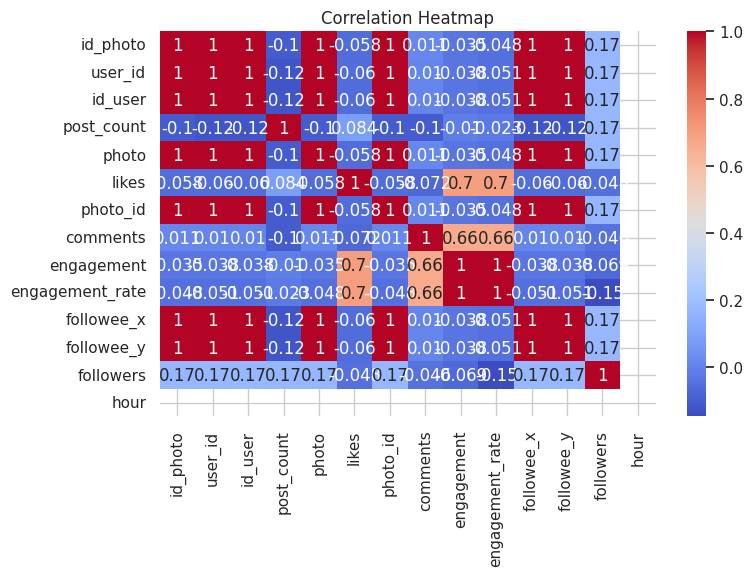

In [26]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**WORD CLOUD**

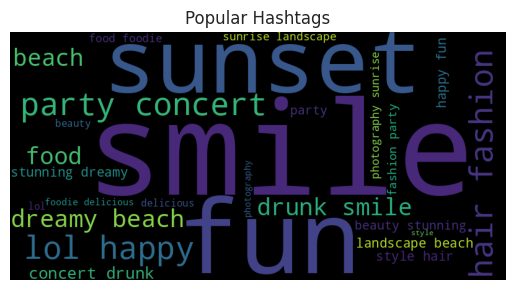

In [27]:
from wordcloud import WordCloud

text = " ".join(tag_data['tag_text'].astype(str))

wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc)
plt.axis('off')
plt.title("Popular Hashtags")
plt.show()

# Optimal Content Calendar for Alfido Tech
##  Based on your analysis:
### Peak engagement: Afternoon to Evening
#### Best days: Tuesday, Wednesday, Thursday
##### Low engagement: Late night & weekends

| Day       | Time     | Content Type            | Purpose               |
| --------- | -------- | ----------------------- | --------------------- |
| Monday    | 3–5 PM   | Educational Post        | Start week with value |
| Tuesday   | 1–5 PM   | Reels                   | High reach            |
| Wednesday | 12–4 PM  | Carousel                | Deep engagement       |
| Thursday  | 2–6 PM   | Reels/Trends            | Growth boost          |
| Friday    | 3–5 PM   | Light/Relatable Content | Maintain activity     |
| Saturday  | Optional | Stories                 | Low effort engagement |
| Sunday    | Avoid    | —                       | Low engagement        |


**5 STRATEGIES TO INCREASE ENGAGEMENT**

1.Post During Peak Hours
    
    
    Focus on afternoon & evening (12–7 PM)

2.Use High-Performing Content Types

👉 Prioritize:

🎥 Reels
📸 Carousels

3.Optimize Hashtags

👉 Use 5–10 relevant hashtags

Mix trending + niche tags
Avoid spam hashtags

4.Maintain Consistency

👉 Post 3–5 times per week

5.Encourage Interaction

👉 Add:
    
    Questions in captions


    Call-to-action (CTA)
    
    
    Polls in stories